# Introduction
This notebook aims to perform kernel nulling on a 4x4 MMI combiner.
Only the DM is expected to be used but using the TOPS instead should be an easy switch.

# Setup

In [1]:
# Libs
import phobos
import numpy as np
import matplotlib.pyplot as plt
import time
import pickle
from tqdm import tqdm
import sys
from pathlib import Path

✅ BMC lib found. Running in control mode.


In [2]:
# Constants
lam = 1551 # [nm]

In [ ]:
# shortcuts
dm = phobos.DM()
cam = phobos.Cred3()
inj_seg = phobos.Config().get('injection.segments')
print('Injected segments:', inj_seg)

# Setup
path = phobos.archive.new('4T2T_hypercube', verbose=True)

# path = Path('/mnt/disk1/archive/2026-06-15_75b9dd8/kernel_null_4x4')

# Spectral calibration
n_roi = 4
spec_law = np.load(path / 'spec_cal_coeffs.npy')
crop_areas = np.array(phobos.Config().get('cred3.output_rectangles'))
crop_areas = crop_areas[:n_roi]
crop_areas = crop_areas[:,[0,2]] # Got the spectral bounds of each track
spectral_axs = np.array([np.arange(crop_areas[i,0], crop_areas[i,-1]) for i in range(crop_areas.shape[0])])
spectral_axs = np.array([np.polyval(spec_law[i], spectral_axs[i]) for i in range(spectral_axs.shape[0])])



DEBUG - SDK Install Path: /opt/Boston Micromachines
DEBUG - BMC_PCIeOpenDM 27BW007#051 0
DEBUG - 1 BMC PCIe cards installed.
DEBUG - Using automatic devId: 1
DEBUG - BMC_PCIeOpenDM opening 0
INFO - PCIe HW Rev: 20000502
DEBUG - Loading map file: /opt/Boston Micromachines/Map/KILO507.map expected count: 1024
INFO - Loading calibration for DM: 27BW07#051_5_3_setof14
DEBUG - Loading map file: /opt/Boston Micromachines/Map/KILO507.map expected count: 1024
Cred3 camera initialized with dark subtraction
Injected segments: [138, 137, 136, 135]
Archive created at /mnt/disk1/archive/2026-06-30_75b9dd8/6_4T2T_hypercube


# Check cropping

✅ Cred3 reset to configuration defaults.


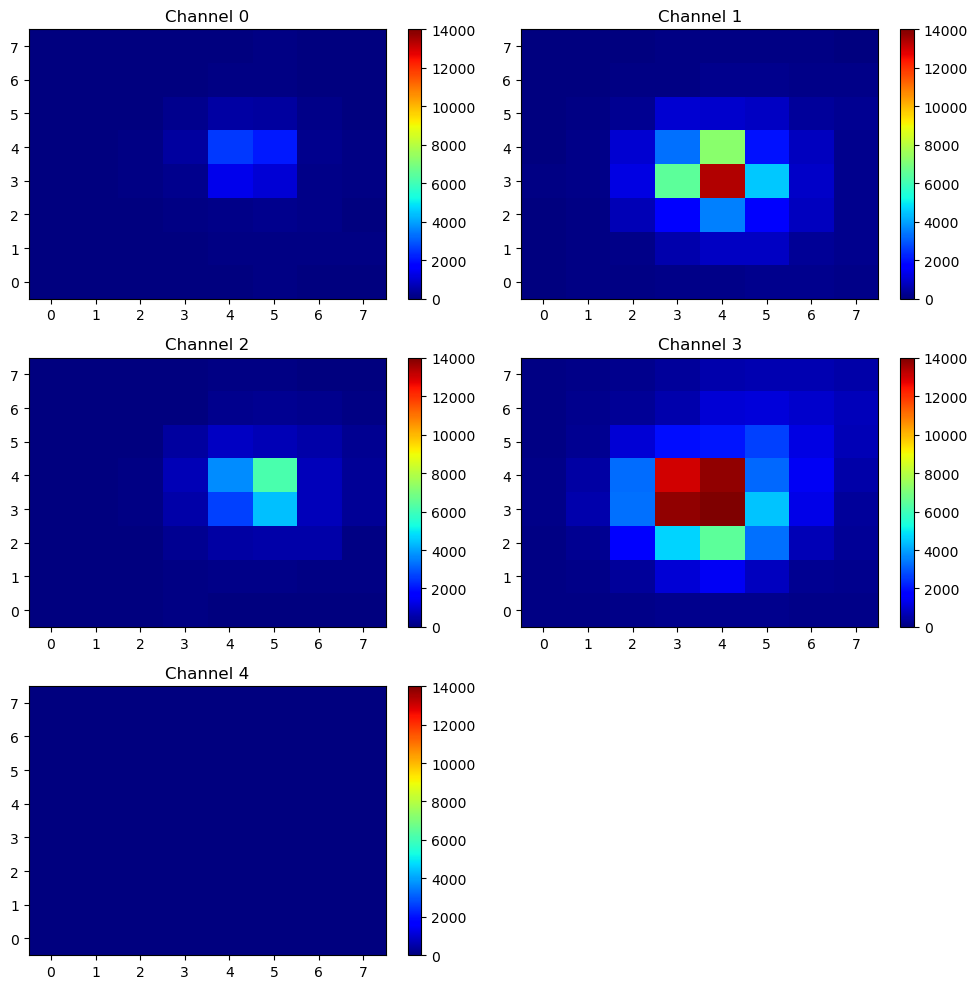

In [4]:
# check cropping
phobos.Config().reload()
cam.reset()
# cam.check_cropping(crop_mode='centers')
cam.check_cropping(crop_mode='centers')

# Calibration injection

In [5]:
# Injection calibration
inj = phobos.Injection()


In [ ]:
# inj.zero()
# maps = inj.get_injection_maps(verbose=True)
# inj.zero()

# fig = plt.figure(figsize=(10,10))
# for i in range(4):
#     image = maps[0][i]
#     tip_range = tilt_ramp = maps[1]
#     tilt_step = np.diff(tilt_ramp)[0]
#     tip_step = np.diff(tip_range)[0]
#     plt.subplot(2,2,i+1)
#     plt.imshow(image, origin='lower', cmap='jet',
#             extent=[tilt_ramp.min()-tilt_step/2, tilt_ramp.max()+tilt_step/2,
#                     tip_range.min()-tip_step/2, tip_range.max()+tip_step/2],
#             vmin=maps[0].min(),
#             vmax=maps[0].max())
#     plt.colorbar()
#     plt.xlabel('Tilt (mrad)')
#     plt.ylabel('Tip (mrad)')
# plt.tight_layout()

Scanning injection maps:   0%|          | 0/4 [00:00<?, ?it/s]

  Channel 0 (segment 138): scanning…
Injection OFF on channels [1, 2, 3] (segments [137, 136, 135])


Scanning injection maps:  25%|██▌       | 1/4 [00:18<00:54, 18.03s/it]

Injection OFF on channels [0] (segments [138])
  Channel 1 (segment 137): scanning…
Injection OFF on channels [0, 2, 3] (segments [138, 136, 135])


Scanning injection maps:  50%|█████     | 2/4 [00:37<00:37, 18.76s/it]

...

Scanning injection maps:  75%|███████▌  | 3/4 [00:59<00:20, 20.37s/it]

Injection OFF on channels [2] (segments [136])
  Channel 3 (segment 135): scanning…
Injection OFF on channels [0, 1, 2] (segments [138, 137, 136])


Scanning injection maps: 100%|██████████| 4/4 [01:16<00:00, 19.15s/it]

Injection OFF on channels [3] (segments [135])
Injection FLAT on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])

── Find gross TT for max injection and spread ──
Injection spread of seg=138: (tip, tilt) = (0.68513,0.75134) mrad
Injection spread of seg=137: (tip, tilt) = (0.71073,0.75662) mrad
Injection spread of seg=136: (tip, tilt) = (0.70627,0.74173) mrad
Injection spread of seg=135: (tip, tilt) = (0.71709,0.77433) mrad

── Find precise TT for max injection ──
Injection max of seg=138: (tip, tilt) = (-0.29454,-0.04684) mrad; flux = 1293
Injection max of seg=137: (tip, tilt) = (0.00347,-0.14427) mrad; flux = 1279
Injection max of seg=136: (tip, tilt) = (0.35874,-0.23016) mrad; flux = 1163
Injection max of seg=135: (tip, tilt) = (0.51263,-0.24348) mrad; flux = 1284
✅ Injection calibration saved to config (injection.max)



── Finding maximum injection points ──

── Balancing injection fluxes ──
  Weakest channel: 2 (seg 136), target flux = 1188
  Dichotomy on channel 0 (seg 138)…
Injection OFF on channels [1, 2, 3] (segments [137, 136, 135])
    → balanced tilt = 0.2086 mrad, flux = 1188 (target 1188), iterations = 13
  Dichotomy on channel 1 (seg 137)…
Injection OFF on channels [0, 2, 3] (segments [138, 136, 135])
    → balanced tilt = 0.0408 mrad, flux = 1194 (target 1188), iterations = 13
  Dichotomy on channel 3 (seg 135)…
Injection OFF on channels [0, 1, 2] (segments [138, 137, 136])
    → balanced tilt = 0.0162 mrad, flux = 1183 (target 1188), iterations = 13
Injection FLAT on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
✅ Injection calibration saved to config (injection.balanced)


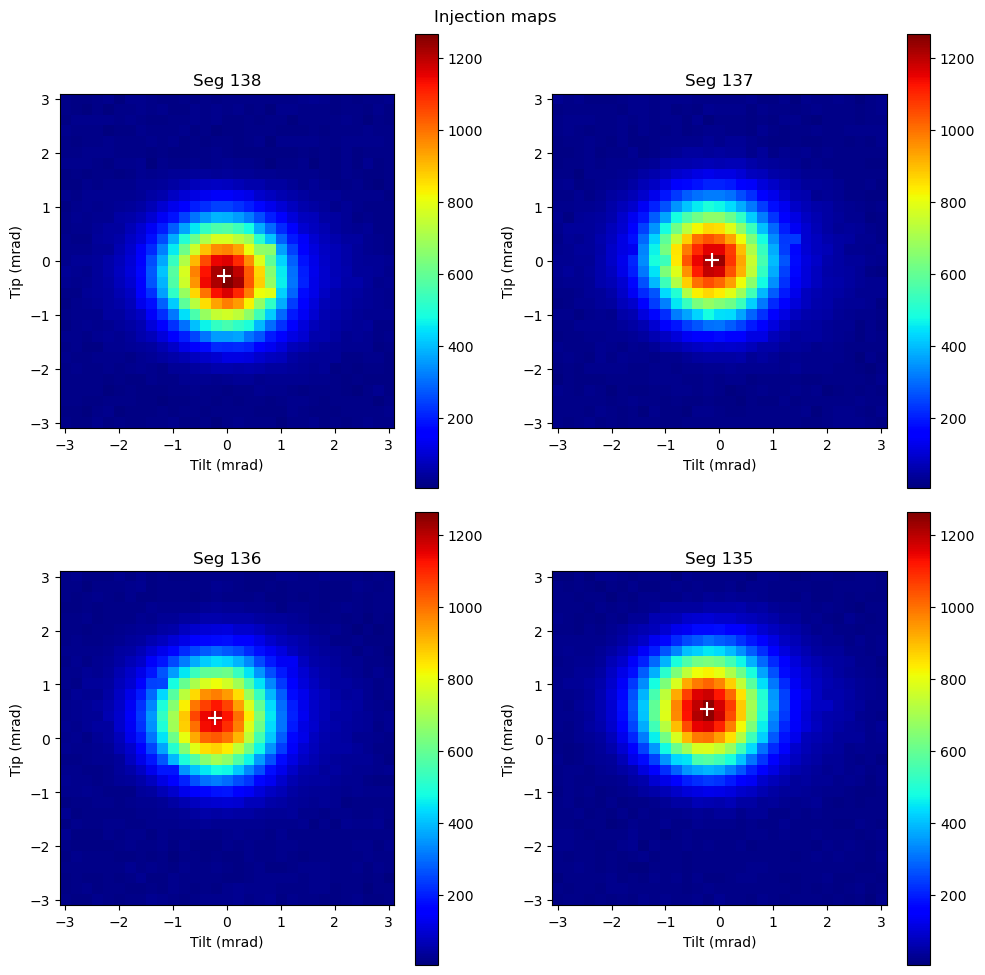

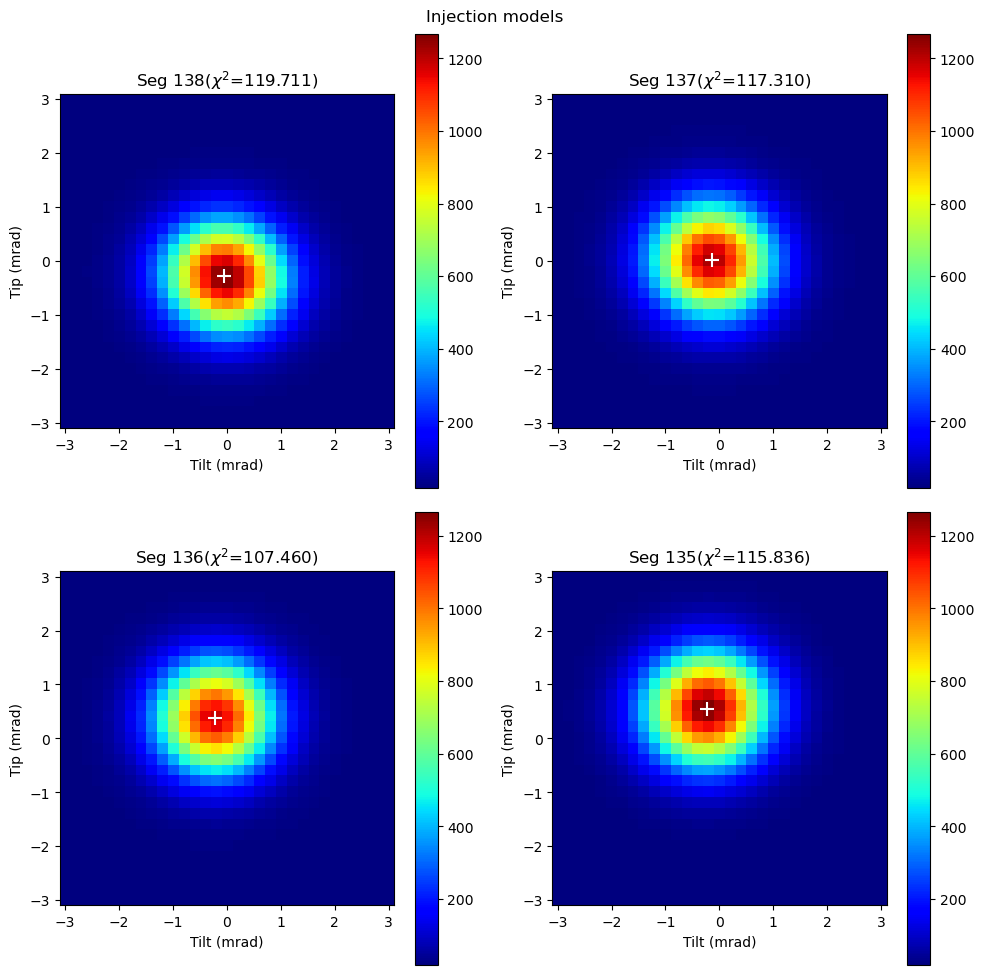

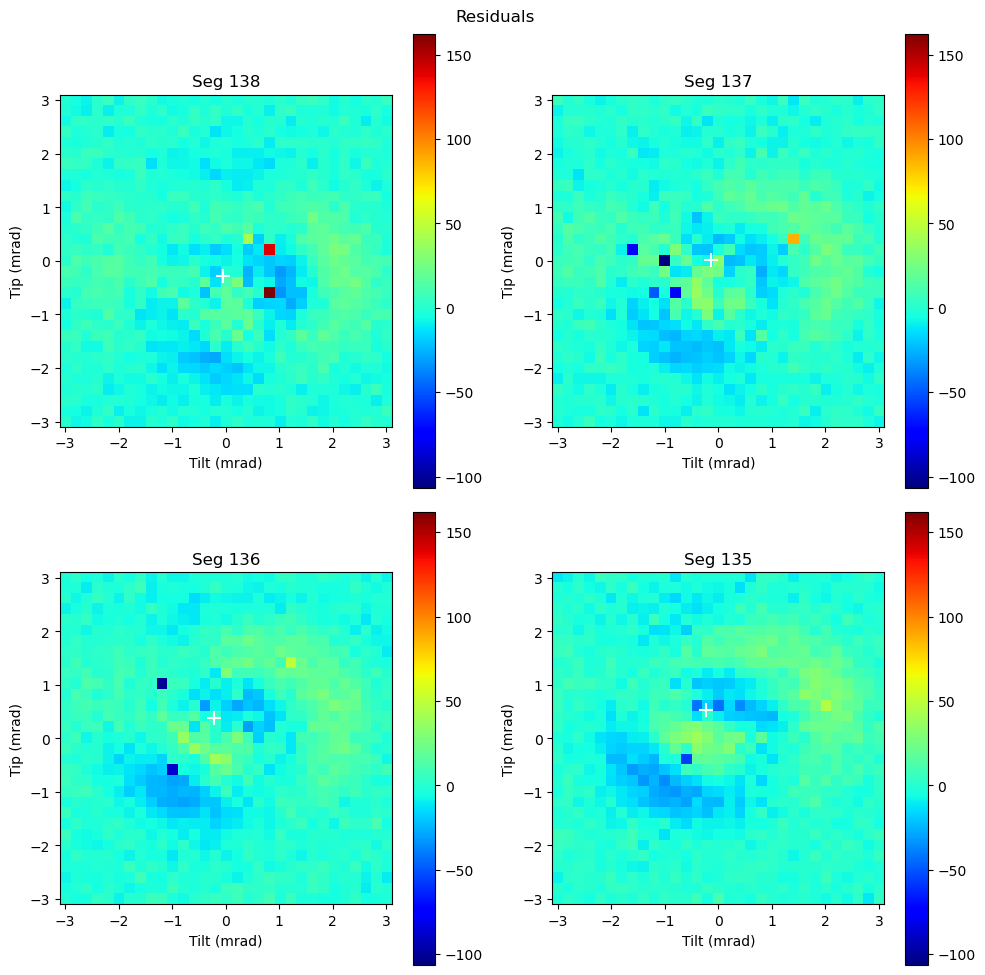

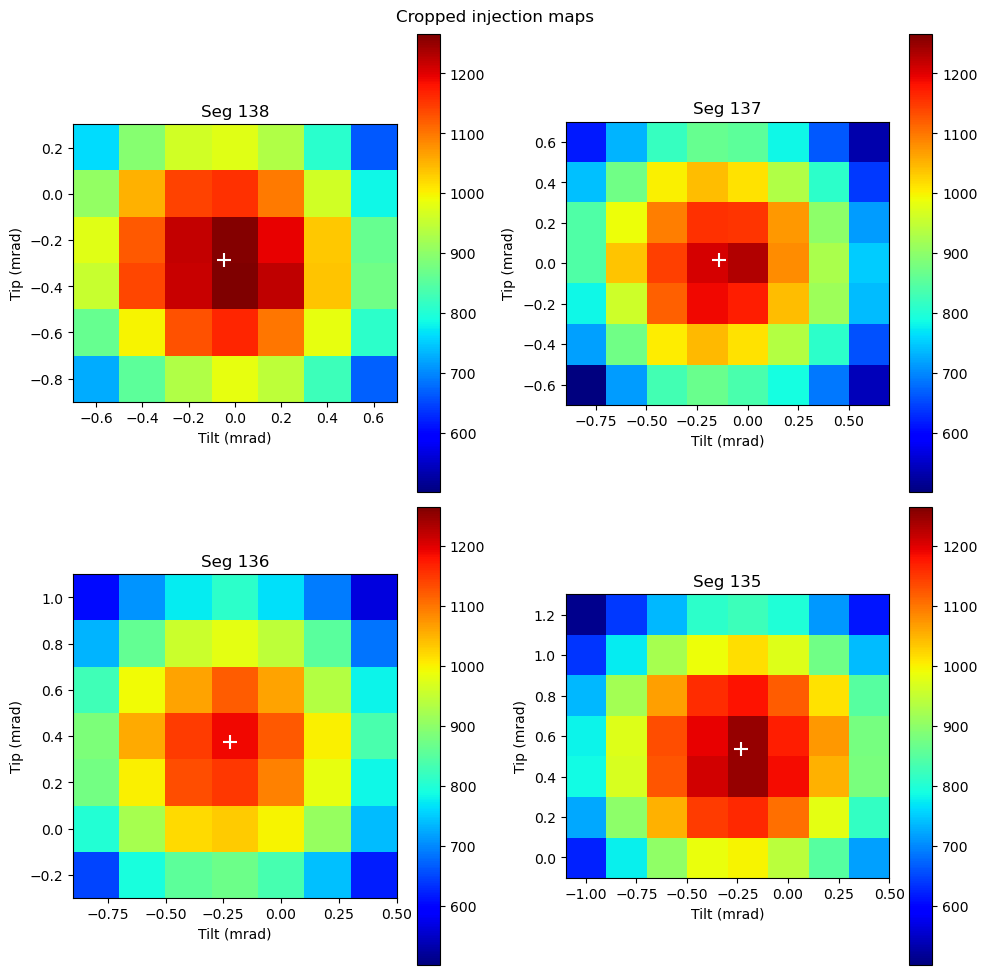

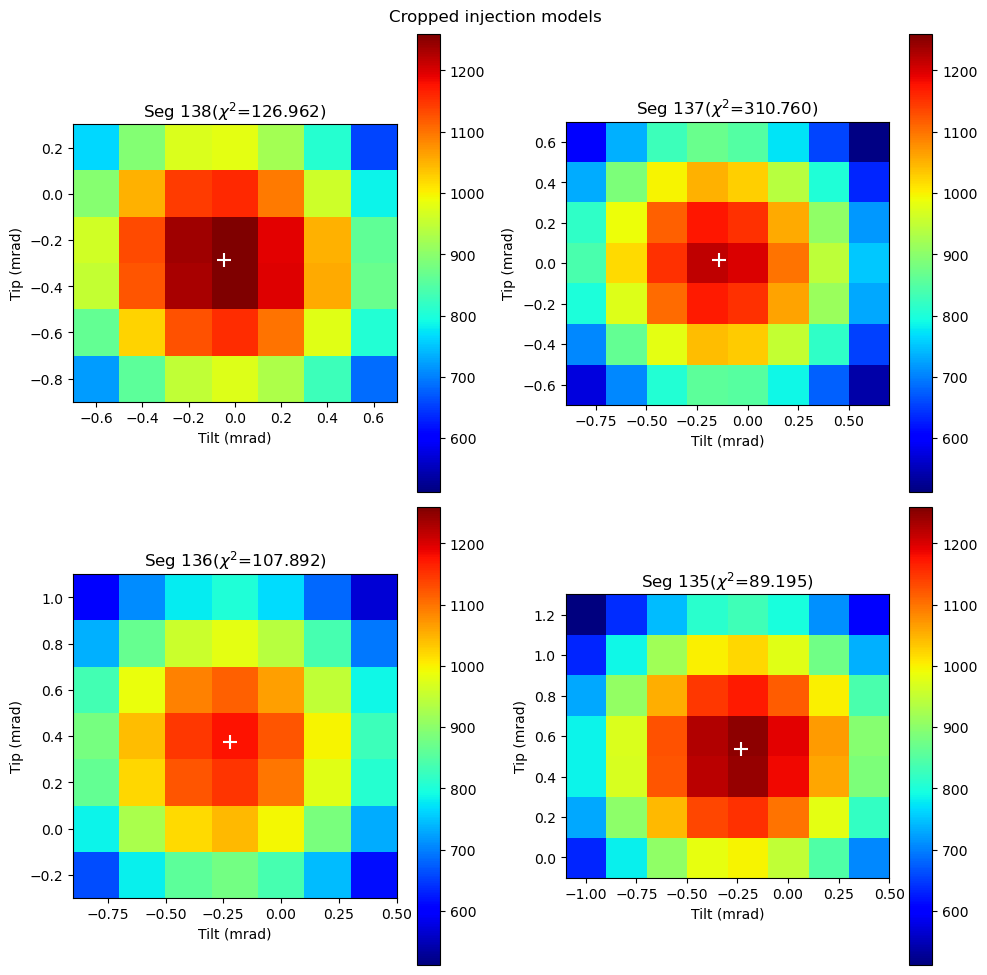

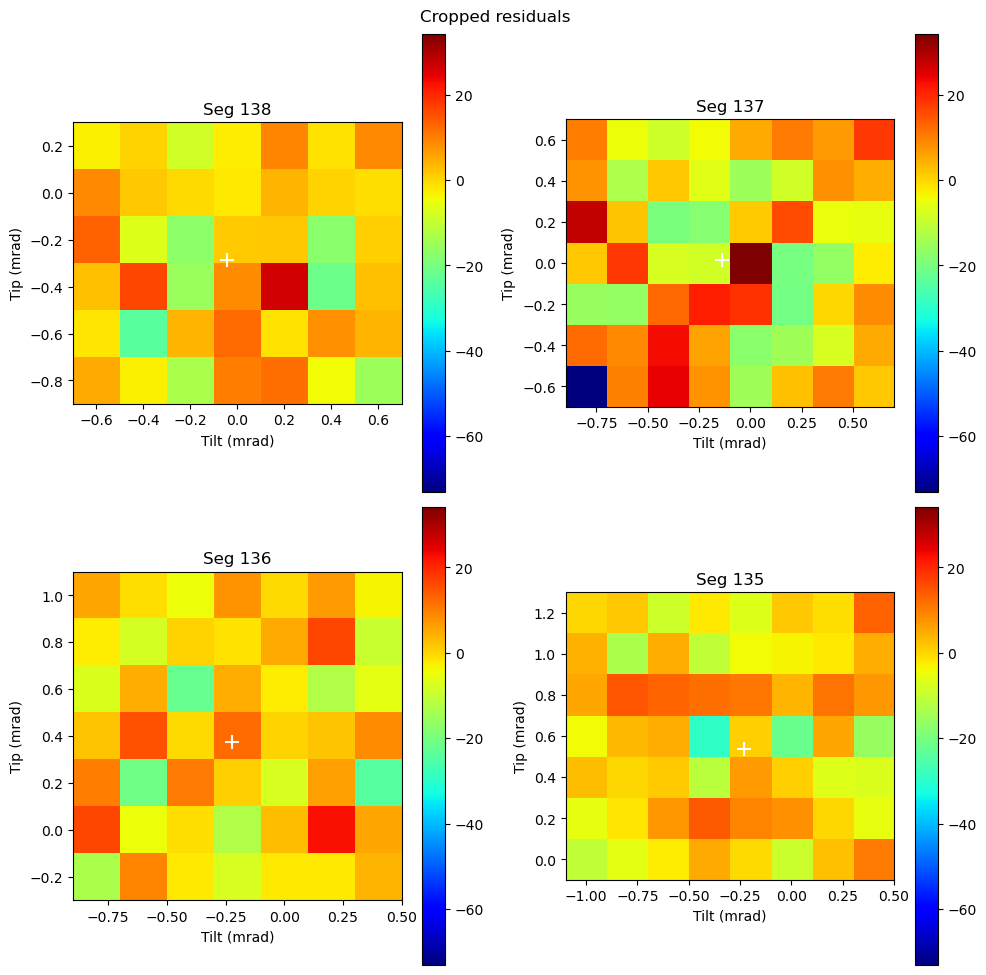

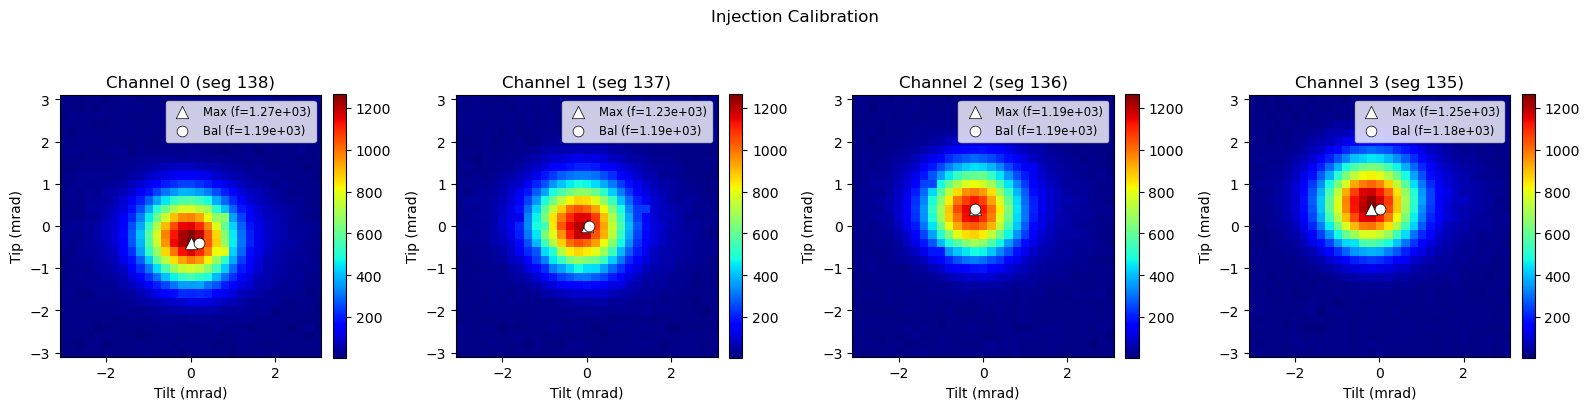

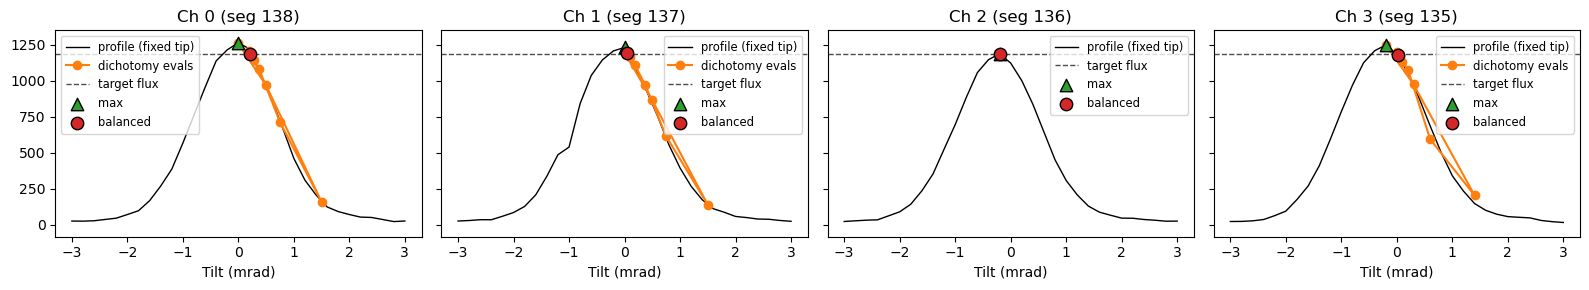

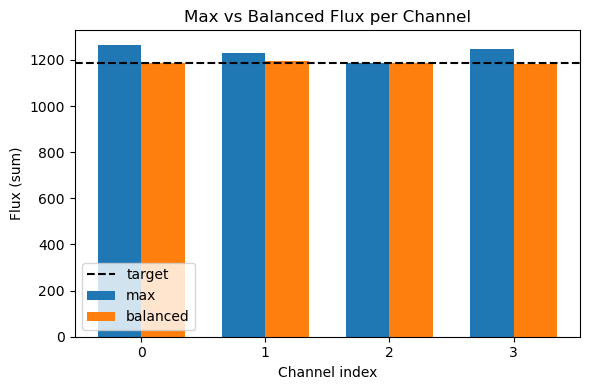

Successfully saved in FITS
Injection ZERO on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


In [6]:
# Injection calibration
avg_frame = 1
avg_frames_bal = 5
out_inj = inj.calibrate(verbose=True, plot=True, save_path=path, 
                        avg_frames=avg_frame, avg_frames_bal=avg_frames_bal,
                        tilt_tol = 0.5e-3, no_balancing=False)

inj.zero()

# Build transfer matrix
Build the transfer matrix of the combiner to identify the different outputs (bright, kernels, double null)

## Measurements of the splitting coefficients

In [ ]:
start = 0.
end = 0.
npoints = 101
n_roi = 4
avg_frames = 10
crop_mode = 'rectangles'

dm_range = np.linspace(start, end, npoints)

# Data acquisition
data = []
for elt in inj_seg:
    inj.set_off(verbose=False)
    inj.set_balanced(elt, verbose=False)
    p0, tip0, tilt0 = dm[elt].get_ptt()

    data_beam = []
    for p in dm_range:
        dm[elt].set_ptt(p, tip0, tilt0)
        time.sleep(0.005)
        out = cam.get_outputs(flux_mode='mean', stack=avg_frames, crop_mode=crop_mode)[:n_roi] # outputs, spectrum

        data_beam.append(out)

    data.append(np.array(data_beam)) # piston, outputs, spectrum

data = np.array(data) # beams, piston, outputs, spectrum

# Data processing
data_normalised = data / data.sum(axis=2, keepdims=True) # sum by outputs

# Splitting ratios
splitting_ratios = data_normalised.mean(axis=1) # mean by piston, shape : beams, spectrum

np.save(path / 'splitting_ratios.npy', splitting_ratios)

In [ ]:
# Display results
title_fs = 20
label_fs = 18
tick_fs = 16
legend_fs = 16

plt.figure(figsize=(10,5))
for k in range(n_roi):
    plt.plot(spectral_axs[k], splitting_ratios[k], label=f'Beam {k+1}')
plt.grid()
plt.xlabel('Wavelength (nm)', fontsize=label_fs)
plt.ylabel('Splitting Ratio', fontsize=label_fs)
plt.legend(loc='best', fontsize=legend_fs)
plt.tick_params(axis='both', which='major', labelsize=tick_fs)
plt.title('Splitting Ratios', fontsize=title_fs)

## Measurements of the phase

In [ ]:
def scan_pair(pair, start, end, nstack, ref_cart):
    inj.off()
    inj.set_balanced(np.array(pair))

    ref_piston = (dm[inj_seg[pair[0]]].get_piston(), dm[inj_seg[pair[1]]].get_piston())
    ref_tip = (dm[inj_seg[pair[0]]].get_tip(), dm[inj_seg[pair[1]]].get_tip())
    ref_tilt = (dm[inj_seg[pair[0]]].get_tilt(), dm[inj_seg[pair[1]]].get_tilt())

    dm[inj_seg[pair[1]]].set_ptt(ref_cart, ref_tip[1], ref_tilt[1])
    piston_range = np.linspace(start, end, 101, endpoint=True)  # [nm]

    # Scan on first input
    outs = np.empty((len(piston_range), n_roi))
    for p, piston in enumerate(tqdm(piston_range)):
        dm[inj_seg[pair[0]]].set_ptt(piston, ref_tip[0], ref_tilt[0])
        if p == 0:
            time.sleep(0.1)
        frame = cam.get_outputs(flux_mode='mean', crop_mode=crop_mode, stack=nstack)[:n_roi]
        outs[p] = frame.mean(1)

    dm[inj_seg[pair[0]]].set_ptt(ref_piston[0], ref_tip[0], ref_tilt[0]) # Re-init segment

    return outs


 